<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/Efficientnet_model_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ১. সমস্যার শুরু — CNN মডেল বড় করার পুরনো পদ্ধতি কেন অদক্ষ ছিল

গভীর শিক্ষার জগতে কনভোলিউশনাল নিউরাল নেটওয়ার্ক (CNN) এর উন্নতি দ্রুত হলেও, সেগুলোকে আরও ভালো করার জন্য গবেষকরা বড় মডেল তৈরি করতেন। এই বড় মডেলগুলোকে বড় করার সময় তিনটি দিককে আলাদাভাবে বাড়ানো হতো:

* **গভীরতা (Depth):** নেটওয়ার্কে আরও বেশি লেয়ার যুক্ত করা (যেমন ResNet-18 থেকে ResNet-152)।
* **প্রস্থ (Width):** প্রতিটি লেয়ারে চ্যানেলের সংখ্যা বাড়ানো (যেমন Wide ResNet)।
* **রেজোলিউশন (Resolution):** ইনপুট ইমেজের আকার বাড়ানো (যেমন 224x224 থেকে 600x600)।

---

## কিন্তু সমস্যা কী ছিল?

পুরনো পদ্ধতিতে এই তিনটি দিকের যেকোনো একটি বাড়ানো হলেই মডেলের কার্যকারিতা কিছুটা বাড়লেও, প্যারামিটারের সংখ্যা অনেক বেড়ে যেত। এটি ভিন্ন ভাবে তিনটি সমস্যা তৈরি করত:

### ১) গণনাগত ব্যয় (Computational Cost)

* বিশাল প্যারামিটারের কারণে মডেলটি চালাতে খুব বেশি সময় এবং প্রসেসিং পাওয়ারের প্রয়োজন হত।

### ২) ওভারফিটিং (Overfitting)

* বড় মডেল ছোট ডেটাসেটে প্রশিক্ষিত হলে ট্রেনিং ডেটা মুখস্থ করে ফেলত, কিন্তু নতুন ডেটাতে ভালো ফল দিত না।

### ৩) স্থানের সংকট (Resource Constraints)

* এত বড় মডেল মোবাইল ফোন বা এজ ডিভাইসে রাখা প্রায় অসম্ভব হয়ে পড়ত।

---

## তাহলে প্রশ্ন হলো —

> কীভাবে এমন একটি মডেল তৈরি করা যায় যা গভীরতা, প্রস্থ, এবং রেজোলিউশন — এই তিনটি দিককেই একসাথে বাড়াবে, কিন্তু প্যারামিটার ও গণনাগত খরচ যুক্তিসঙ্গত সীমার মধ্যে রাখবে?


# ২. EfficientNet-এর উদ্ভাবন — কম্পাউন্ডেড স্কেলিং (Compound Scaling)

EfficientNet এই সমস্যার সমাধান এনেছে। এর মূল কথা হলো:

> গভীরতা, প্রস্থ, আর রেজোলিউশন — এই তিনটিকে আলাদাভাবে না বাড়িয়ে, এদেরকে একটি নির্দিষ্ট অনুপাতে একসাথে বাড়ানো।

একেই বলে **কম্পাউন্ডেড স্কেলিং (Compound Scaling)**।

---

## সহজ উদাহরণ

ধরা যাক, আপনার হাতে একটি বেস মডেল আছে (যার নাম EfficientNet-B0)।

এখন আপনি যদি এটিকে ২ গুণ বড় করতে চান, তাহলে আপনি শুধু:

* লেয়ারের সংখ্যা দ্বিগুণ করবেন না
* বা শুধু চ্যানেল বাড়াবেন না

বরং, EfficientNet নির্ধারিত অ্যালগরিদম অনুযায়ী স্থির করে দেয়:

* দালানের উচ্চতা (গভীরতা) কিছুটা বাড়বে
* প্রস্থ (চওড়া) কিছুটা বাড়বে
* জানালার সাইজ (রেজোলিউশন) কিছুটা বড় হবে

---

## মূল ধারণা

তিনটি দিকই একটি নির্দিষ্ট সূত্রের মাধ্যমে সমানুপাতিক হারে বাড়বে।

এই সূত্রটির নাম:

Compound Scaling


# ৩. CNN-এর তিনটি স্কেলিং ডাইমেনশনের সহজ ব্যাখ্যা

EfficientNet-এর তিনটি ডাইমেনশন বোঝা জরুরি। নিচে এদের সহজ ব্যাখ্যা দেওয়া হলো।

---

# ৩.১ গভীরতা (Depth)

## মানে কী?

* নেটওয়ার্কে লেয়ার সংখ্যা কত।

## উদাহরণ

* ResNet-18 এর চেয়ে ResNet-50 বেশি গভীর।

## সুবিধা

* বেশি লেয়ার থাকলে মডেল আরও জটিল ফিচার শিখতে পারে।

## অসুবিধা

* অতিরিক্ত গভীর হলে গ্রেডিয়েন্ট ভ্যানিশ বা এক্সপ্লোডের সমস্যা দেখা দিতে পারে।

---

# ৩.২ প্রস্থ (Width)

## মানে কী?

* প্রতিটি লেয়ারের চ্যানেল সংখ্যা কত।

## উদাহরণ

* সাধারন কনভোলিউশনে ৩২টি চ্যানেলের বদলে ৬৪টি চ্যানেল ব্যবহার করলে প্রস্থ বাড়ে।

## সুবিধা

* বেশি চ্যানেল থাকলে মডেল বিভিন্ন ধরনের ফিচার ধারণ করতে পারে।

## অসুবিধা

* চ্যানেল বাড়ালে প্যারামিটার এবং হিসাবের পরিমাণ দ্রুত বেড়ে যায়।

---

# ৩.৩ রেজোলিউশন (Resolution)

## মানে কী?

* ইনপুট ইমেজের উচ্চতা ও প্রস্থ কত।

## উদাহরণ

* 224x224 পিক্সেলের ইমেজের পরিবর্তে 512x512 পিক্সেল ব্যবহার।

## সুবিধা

* বেশি রেজোলিউশনে ছোট ছোট ডিটেইল ভালোভাবে বোঝা যায়।

## অসুবিধা

* মেমরির ব্যবহার আরও বেড়ে যায় এবং গণনাও ব্যয়বহুল হয়।


# ৪. EfficientNet-এর বেসলাইন আর্কিটেকচার — EfficientNet-B0

EfficientNet-এর সবচেয়ে ছোট মডেলটির নাম EfficientNet-B0। এটি EfficientNet পরিবারের ভিত্তি।

---

# EfficientNet-B0 Architecture Table

| স্টেজ | অপারেটর (Operator)         | রেজোলিউশন | চ্যানেল সংখ্যা | লেয়ার সংখ্যা |
| ----- | -------------------------- | --------- | -------------- | ------------- |
| 1     | কনভোলিউশন (3x3)            | 224 × 224 | 32             | 1             |
| 2     | MBConv1, k3x3              | 112 × 112 | 16             | 1             |
| 3     | MBConv6, k3x3              | 112 × 112 | 24             | 2             |
| 4     | MBConv6, k5x5              | 56 × 56   | 40             | 2             |
| 5     | MBConv6, k3x3              | 28 × 28   | 80             | 3             |
| 6     | MBConv6, k5x5              | 14 × 14   | 112            | 3             |
| 7     | MBConv6, k5x5              | 14 × 14   | 192            | 4             |
| 8     | MBConv6, k3x3              | 7 × 7     | 320            | 1             |
| 9     | কনভোলিউশন (1x1), পুলিং, FC | 7 × 7     | 1280           | 1             |

---

# সহজ ভাষায় টেবিলটির অর্থ

## স্টেজ (Stage)

* নেটওয়ার্কের একটি অংশ।
* যেমন স্টেজ ২-৮ মূল ফিচার বের করার অংশ।

## MBConv

* এটি EfficientNet-এর মূল বিল্ডিং ব্লক (Mobile Inverted Bottleneck Convolution)।

## k3x3 বা k5x5

* কনভোলিউশন ফিল্টারের সাইজ।

## রেজোলিউশন

* ইমেজের আকার যা ধাপে ধাপে ছোট হতে থাকে।

## চ্যানেল সংখ্যা

* ফিচার ম্যাপের গভীরতা।

## লেয়ার সংখ্যা

* এই স্টেজে MBConv ব্লক কতবার পুনরাবৃত্তি হবে।


# ৫. MBConv ব্লক কী এবং কেন এটি এত বিশেষ?

MBConv (Mobile Inverted Bottleneck Convolution) হলো EfficientNet-এর মূল ভিত্তি। এটি MobileNetV2 থেকেই নেওয়া।

---

# একটি MBConv ব্লকের ভিতরের কাজ

## ১) Expansion Phase

* প্রথমে 1x1 কনভোলিউশন ব্যবহার করে ইনপুট চ্যানেলের সংখ্যা বাড়ানো হয়।
* উদাহরণ: 16 চ্যানেল থেকে 96 চ্যানেল করা।

---

## ২) Depth-wise Convolution

* 3x3 বা 5x5 সাইজের একটি ফিল্টার ব্যবহার করে প্রতিটি চ্যানেল আলাদাভাবে প্রক্রিয়া করা হয়।
* এটি ফিচার এক্সট্র্যাক্ট করে।

---

## ৩) Squeeze-and-Excitation (SE Block)

এটি একটি অ্যাটেনশন মেকানিজম।

### কাজ:

* গুরুত্বপূর্ণ চ্যানেলগুলোকে জোরালো করে
* অগুরুত্বপূর্ণ চ্যানেলগুলোকে দুর্বল করে দেয়

---

## ৪) Projection Phase

* আবার 1x1 কনভোলিউশন ব্যবহার করে চ্যানেলের সংখ্যা আগের অবস্থায় ফিরিয়ে আনা হয়।

---

## ৫) Skip Connection

* যদি ইনপুট এবং আউটপুটের চ্যানেল সংখ্যা ও সাইজ সমান থাকে, তাহলে ব্লকের শুরু ও শেষ যুক্ত করে দেওয়া হয়।
* এটি ResNet থেকে নেওয়া ধারণা।

---

# ৫.১ ডেপথওয়াইজ সিপারেবল কনভোলিউশন (Depth-wise Separable Convolution)

এটি একটি বিশেষ কৌশল।

---

## ডেপথওয়াইজ কনভোলিউশন

* প্রতিটি চ্যানেলের জন্য আলাদা ফিল্টার ব্যবহার করে ফিচার বের করে।
* এটি প্যারামিটার অনেক কম খরচ করে।

---

## পয়েন্টওয়াইজ কনভোলিউশন

* 1x1 ফিল্টার ব্যবহার করে চ্যানেলগুলির মধ্যে সম্পর্ক তৈরি করে।

---

# সহজ ভাষায়

> কম প্যারামিটার ব্যবহার করেও একই কাজ করা যায়।


# ৬. EfficientNet-এ কম্পাউন্ডেড স্কেলিং এর সূত্র

মনে করি, EfficientNet-B0 (বেসলাইন মডেল) একটি ছোট ঘর।

এখন আমরা এই বেসলাইন মডেলটিকে বড় সংস্করণে এনে নাম দেব:

* EfficientNet-B1
* EfficientNet-B2
* ...
* EfficientNet-B7

---

# Compound Scaling Formula

$$
\text{depth}=\alpha^{\phi},\quad
\text{width}=\beta^{\phi},\quad
\text{resolution}=\gamma^{\phi}
$$

---

# এখানে,

## φ (ফাই)

* এটি একটি সংখ্যা।
* φ এর মান যত বাড়বে, মডেল তত বড় হবে।

---

## α, β, γ

* এগুলো ধ্রুবক মান।
* এরা স্থির করে দেয় যে φ-এর মান পরিবর্তনের সাথে সাথে গভীরতা, প্রস্থ ও রেজোলিউশনের অনুপাত কেমন হবে।

---

# উদাহরণ

* φ = 1 → EfficientNet-B0
* φ = 2 → EfficientNet-B1
* φ = 3 → EfficientNet-B2
* φ = 7 → EfficientNet-B7


# ৭. EfficientNet পরিবারের বিভিন্ন সংস্করণ (B0 থেকে B7)

EfficientNet পরিবারে মোট 8টি সংস্করণ রয়েছে।

---

# বিভিন্ন সংস্করণ

* **EfficientNet-B0:** সবচেয়ে ছোট (সবচেয়ে কম প্যারামিটার)
* **EfficientNet-B1**
* **EfficientNet-B2**
* **EfficientNet-B3**
* **EfficientNet-B4**
* **EfficientNet-B5**
* **EfficientNet-B6**
* **EfficientNet-B7:** সবচেয়ে বড় এবং সবচেয়ে নির্ভুল মডেল

---

# গুরুত্বপূর্ণ তথ্য

> B7 মডেলটি B0 থেকে প্রায় ৭ গুণ বড়, কিন্তু প্যারামিটার ও গণনাগত খরচ চার-পাঁচ গুণ বেড়েছে, যা অনেক যুক্তিসঙ্গত।

---

# Accuracy

* EfficientNet-B7 ইমেজনেট ডেটাসেটে ৮৪.৪% নির্ভুলতা অর্জন করে।


# ৮. পূর্ববর্তী মডেলগুলোর সাথে Efficiency ও Accuracy এর তুলনা

EfficientNet তার কম্পাউন্ডেড স্কেলিং কৌশলের জন্য পুরনো মডেলগুলোর তুলনায় অনেক বেশি কার্যকর।

---

# তুলনামূলক সুবিধা

## ১) প্যারামিটার অনেক কম

* EfficientNet-B7-এর নির্ভুলতা InceptionV3-এর মতো,
* কিন্তু প্যারামিটার প্রায় ৮ গুণ কম।

---

## ২) গণনা কম

* EfficientNet-B7 ResNet-50-এর চেয়ে অনেক বেশি নির্ভুল,
* কিন্তু গণনায় প্রায় ৭ গুণ দ্রুত।

---

## ৩) ছোট আকার

* EfficientNet-B4 ইমেজনেটে ৮২.২% নির্ভুলতা দেয়,
* তবুও ফাইল সাইজে ছোট।

---

# সংক্ষেপে

> EfficientNet পুরনো মডেলগুলোর তুলনায় আকারে ছোট, দ্রুতগতির, এবং নির্ভুলতায় উন্নত।


# ৯. EfficientNet-এর কিছু সুবিধা ও অবদান

EfficientNet আমাদের গুরুত্বপূর্ণ কিছু বিষয় শিখিয়েছে।

---

# প্রধান অবদানসমূহ

## ১) সঠিক স্কেলিং কৌশল জরুরি

* শুধু বড় মডেল বানালেই হবে না।
* সেটি কীভাবে স্কেল করবেন সেটিও গুরুত্বপূর্ণ।

---

## ২) সব মাত্রার মধ্যে ভারসাম্য রাখা দরকার

* গভীরতা, প্রস্থ ও রেজোলিউশন একসাথে বাড়ালে সবচেয়ে ভালো ফল পাওয়া যায়।

---

## ৩) Automated Architecture Search (NAS)

* EfficientNet-এর বেস মডেলটিও তৈরি করার জন্য Automated Machine Learning ব্যবহার করা হয়েছিল।
* এটি MnasNet থেকে নেওয়া।

---

## ৪) ব্যবহারিক গুরুত্ব

* কম রিসোর্সে (মোবাইল, এজ ডিভাইস) EfficientNet দিয়ে উচ্চমানের ফলাফল পাওয়া যায়।


# ১০. উপসংহার

EfficientNet একটি যুগান্তকারী অগ্রগতি।

এটি প্রমাণ করেছে যে:

* মডেলের কার্যকারিতা শুধু গভীরতা বা প্রস্থ বা রেজোলিউশনের ওপর নির্ভর করে না
* বরং এদের একটি সঠিক কম্পাউন্ড স্কেলিং-এর ওপর নির্ভর করে

---

# মূল শিক্ষা

## EfficientNet দেখিয়েছে:

✅ সঠিক স্কেলিং কৌশল অত্যন্ত গুরুত্বপূর্ণ
✅ গভীরতা, প্রস্থ ও রেজোলিউশনের মধ্যে ভারসাম্য রাখা দরকার
✅ কম রিসোর্সেও শক্তিশালী CNN তৈরি করা সম্ভব

---

# শেষ কথা

> EfficientNet আধুনিক CNN আর্কিটেকচারের জগতে একটি বড় পরিবর্তন নিয়ে এসেছে।


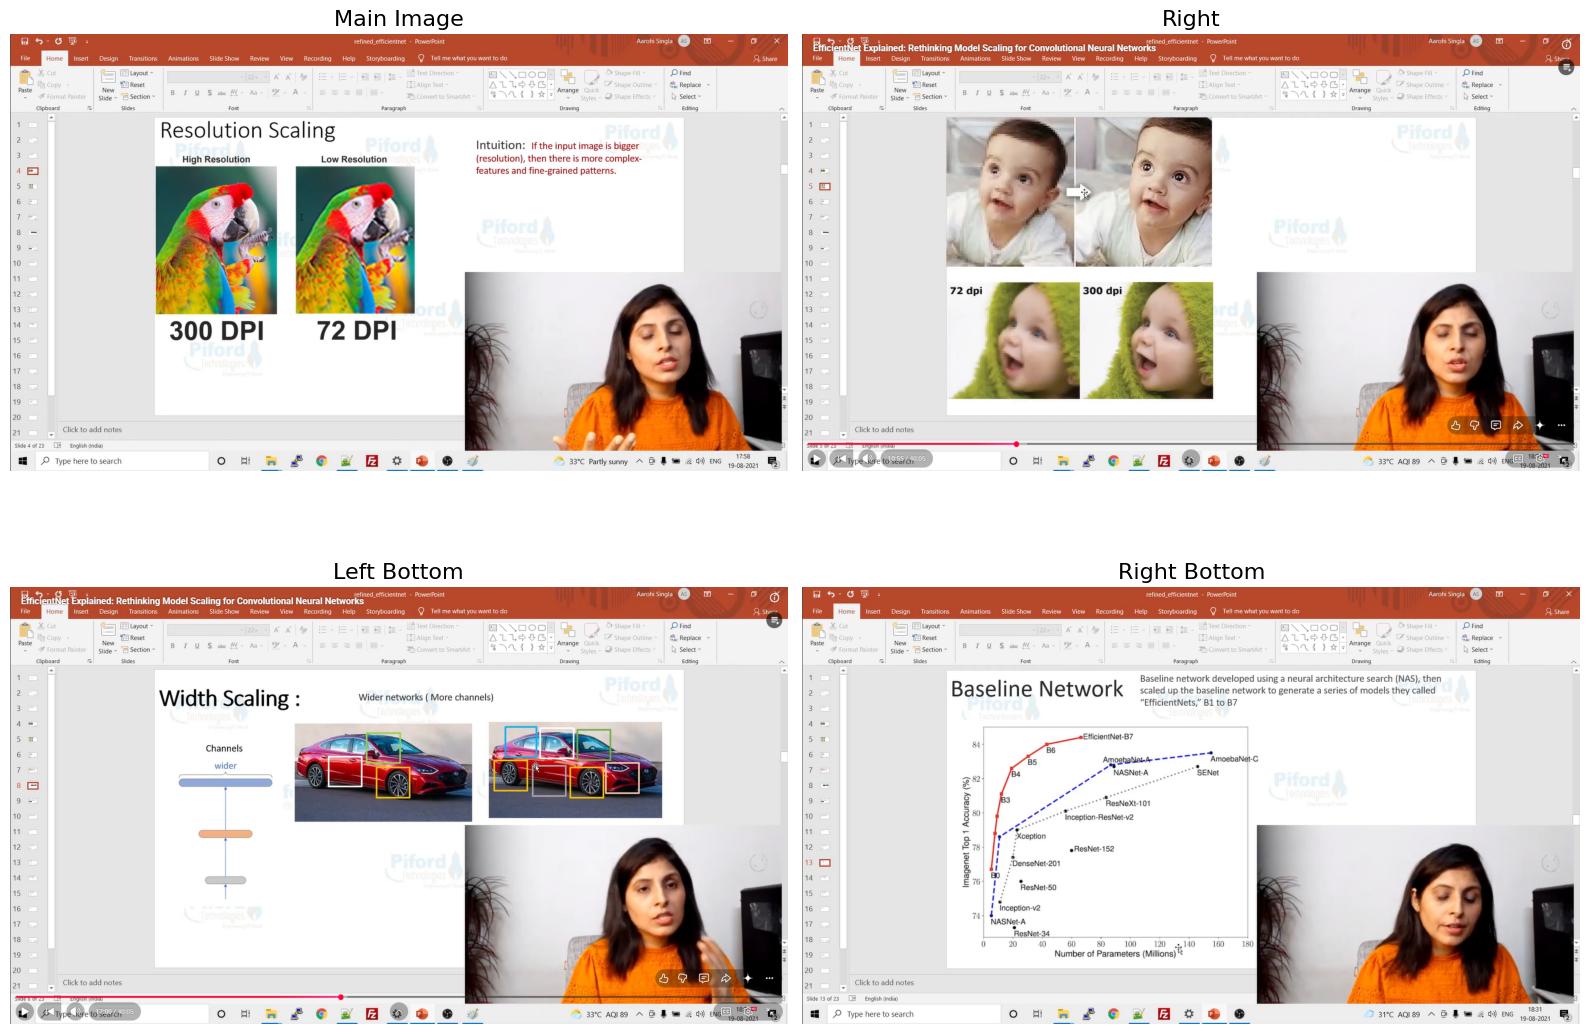

In [3]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/Screenshot 2026-05-08 134948.png')
right_img = Image.open('/content/Screenshot 2026-05-08 135010.png')
left_bottom_img = Image.open('/content/Screenshot 2026-05-08 135039.png')
right_bottom_img = Image.open('/content/Screenshot 2026-05-08 135126.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')
plt.title("Main Image", fontsize=16)

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')
plt.title("Right", fontsize=16)

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')
plt.title("Left Bottom", fontsize=16)

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')
plt.title("Right Bottom", fontsize=16)

# Space adjustment
plt.tight_layout()

plt.show()

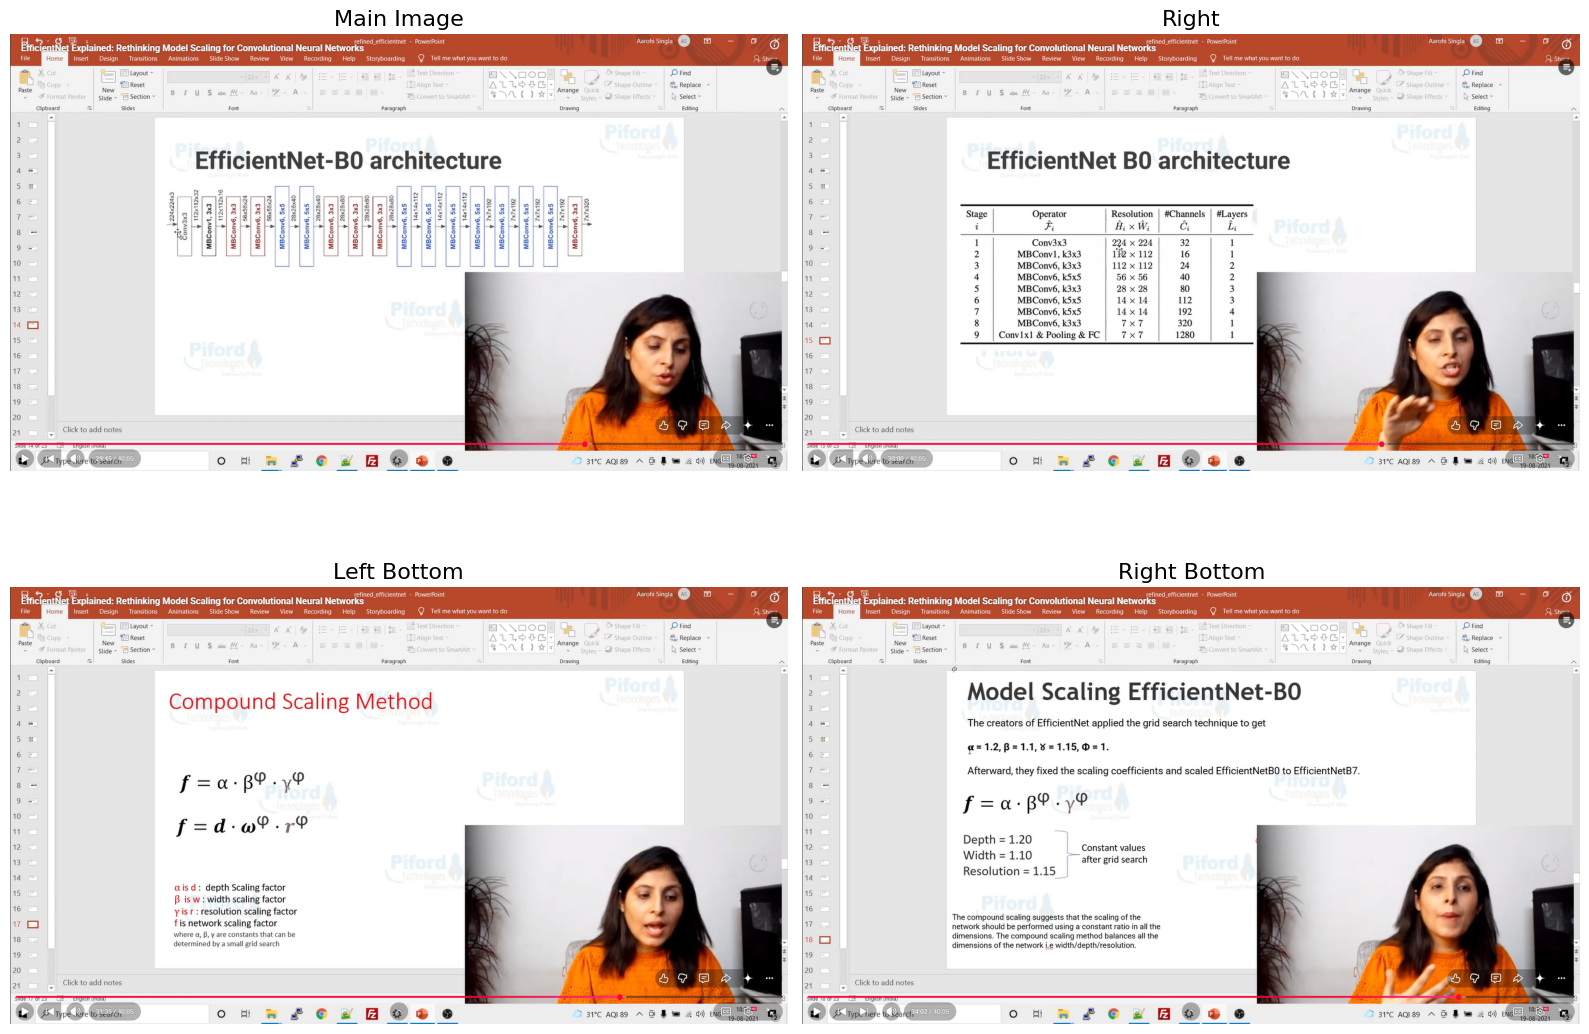

In [4]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/Screenshot 2026-05-08 135155.png')
right_img = Image.open('/content/Screenshot 2026-05-08 135202.png')
left_bottom_img = Image.open('/content/Screenshot 2026-05-08 135212.png')
right_bottom_img = Image.open('/content/Screenshot 2026-05-08 135234.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')
plt.title("Main Image", fontsize=16)

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')
plt.title("Right", fontsize=16)

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')
plt.title("Left Bottom", fontsize=16)

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')
plt.title("Right Bottom", fontsize=16)

# Space adjustment
plt.tight_layout()

plt.show()

Using device: cuda


100%|██████████| 170M/170M [02:48<00:00, 1.01MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

Epoch [1/5]: 100%|██████████| 782/782 [04:18<00:00,  3.02it/s, acc=88.5, loss=0.648]


...

Epoch [4/5] - Loss: 0.1064, Accuracy: 96.31%


Epoch [5/5]: 100%|██████████| 782/782 [04:21<00:00,  2.99it/s, acc=96.9, loss=0.0135]


Epoch [5/5] - Loss: 0.0911, Accuracy: 96.90%

Testing Started...


Testing: 100%|██████████| 157/157 [00:20<00:00,  7.52it/s]



Test Accuracy: 93.47%

Class-wise Accuracy:
plane     : 92.90%
car       : 97.40%
bird      : 92.40%
cat       : 90.90%
deer      : 96.80%
dog       : 89.80%
frog      : 89.90%
horse     : 94.90%
ship      : 98.00%
truck     : 91.70%


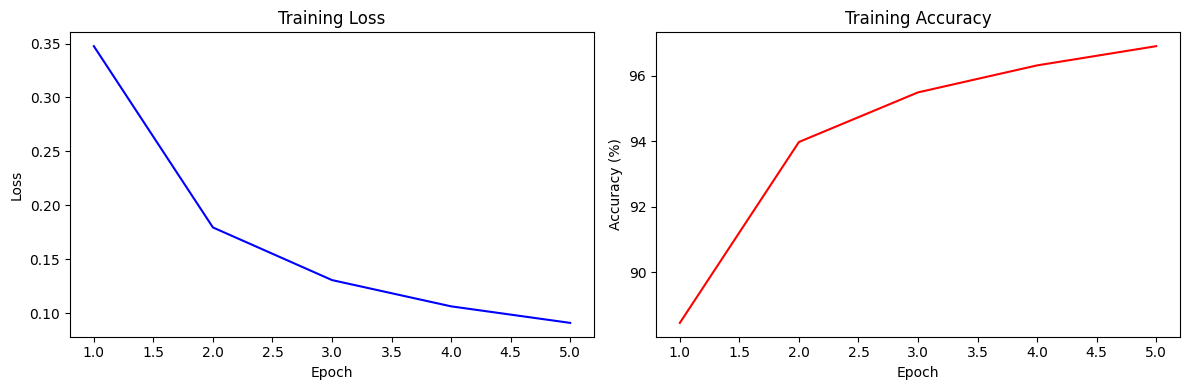


Model saved as 'efficientnet_cifar10.pth'


In [1]:
# ============================================
# ১. প্রয়োজনীয় লাইব্রেরি ইমপোর্ট করা
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm  # প্রগ্রেস বার দেখানোর জন্য
import matplotlib.pyplot as plt

# ============================================
# ২. ডিভাইস সেটআপ (GPU থাকলে GPU, না হলে CPU)
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================
# ৩. ডেটাসেট লোড করা (CIFAR-10 - ছোট ও দ্রুত)
# ============================================
# CIFAR-10: 10টি ক্লাসের 32x32 রঙিন ছবি
transform = transforms.Compose([
    transforms.Resize(224),  # EfficientNet 224x224 ইনপুট নেয়
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet মান
                         std=[0.229, 0.224, 0.225])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# ব্যাচ সাইজ কম রাখা হয়েছে (দ্রুত training-এর জন্য)
batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# ক্লাসের নাম (CIFAR-10 এর জন্য)
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# ============================================
# ৪. EfficientNet মডেল লোড করা (Pretrained)
# ============================================
# timm লাইব্রেরি থেকে EfficientNet-B0 ব্যবহার করছি
!pip install timm -q  # timm না থাকলে ইনস্টল করবে
import timm

model = timm.create_model('efficientnet_b0', pretrained=True)

# CIFAR-10-এর জন্য শেষ লেয়ার পরিবর্তন (10 টি ক্লাস)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 10)

model = model.to(device)

print(model)  # মডেলের আর্কিটেকচার দেখাবে

# ============================================
# ৫. Loss ফাংশন ও Optimizer নির্ধারণ
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ============================================
# ৬. ট্রেনিং ফাংশন
# ============================================
def train_model(model, trainloader, criterion, optimizer, epochs=5):
    model.train()
    train_losses = []
    train_accs = []

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # tqdm দিয়ে প্রগ্রেস বার দেখানো হবে
        loop = tqdm(trainloader, desc=f'Epoch [{epoch+1}/{epochs}]')
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            # ফরওয়ার্ড পাস
            outputs = model(images)
            loss = criterion(outputs, labels)

            # ব্যাকওয়ার্ড পাস ও অপটিমাইজ
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # স্ট্যাটিস্টিক্স গণনা
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # প্রগ্রেস বার আপডেট
            loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        print(f'Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

    return train_losses, train_accs

# ============================================
# ৭. টেস্টিং ফাংশন
# ============================================
def test_model(model, testloader):
    model.eval()
    correct = 0
    total = 0
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    with torch.no_grad():
        for images, labels in tqdm(testloader, desc='Testing'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # ক্লাস-ভিত্তিক অ্যাকুরেসি গণনা
            c = (predicted == labels).squeeze()
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    print(f'\nTest Accuracy: {100. * correct / total:.2f}%')
    print('\nClass-wise Accuracy:')
    for i in range(10):
        print(f'{classes[i]:10s}: {100. * class_correct[i] / class_total[i]:.2f}%')

    return 100. * correct / total

# ============================================
# ৮. মডেল ট্রেনিং শুরু করা
# ============================================
print("\n" + "="*50)
print("Training Started...")
print("="*50)

train_losses, train_accs = train_model(model, trainloader, criterion, optimizer, epochs=5)

# ============================================
# ৯. মডেল টেস্ট করা
# ============================================
print("\n" + "="*50)
print("Testing Started...")
print("="*50)

test_acc = test_model(model, testloader)

# ============================================
# ১০. ফলাফল ভিজুয়ালাইজেশন
# ============================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accs)+1), train_accs, 'r-')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')

plt.tight_layout()
plt.show()

# ============================================
# ১১. মডেল সেভ করা
# ============================================
torch.save(model.state_dict(), 'efficientnet_cifar10.pth')
print("\nModel saved as 'efficientnet_cifar10.pth'")